In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
URL = "https://gist.github.com/slopp/ce3b90b9168f2f921784de84fa445651/raw/4ecf3041f0ed4913e7c230758733948bc561f434/penguins.csv"

In [2]:
from urllib.request import urlretrieve
urlretrieve(URL, "penguins.csv")

('penguins.csv', <http.client.HTTPMessage at 0x127d1ea10>)

In [3]:
data1 = pd.read_csv("penguins.csv")

In [4]:
data2 = pd.read_csv("penguins.csv", index_col = 'rowid')
columns_to_delete = ['sex', 'island']
rows_to_delete = [4, 272]
data2.drop(columns=columns_to_delete ,index=rows_to_delete, inplace = True)

In [5]:
data2

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
rowid,,,,,,
1,Adelie,39.1,18.7,181.0,3750.0,2007
2,Adelie,39.5,17.4,186.0,3800.0,2007
3,Adelie,40.3,18.0,195.0,3250.0,2007
5,Adelie,36.7,19.3,193.0,3450.0,2007
6,Adelie,39.3,20.6,190.0,3650.0,2007
...,...,...,...,...,...,...
340,Chinstrap,55.8,19.8,207.0,4000.0,2009
341,Chinstrap,43.5,18.1,202.0,3400.0,2009
342,Chinstrap,49.6,18.2,193.0,3775.0,2009


In [6]:
data1.head()

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [7]:
data1.columns.values

array(['rowid', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'], dtype=object)

/Users/gurbakshmunday/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


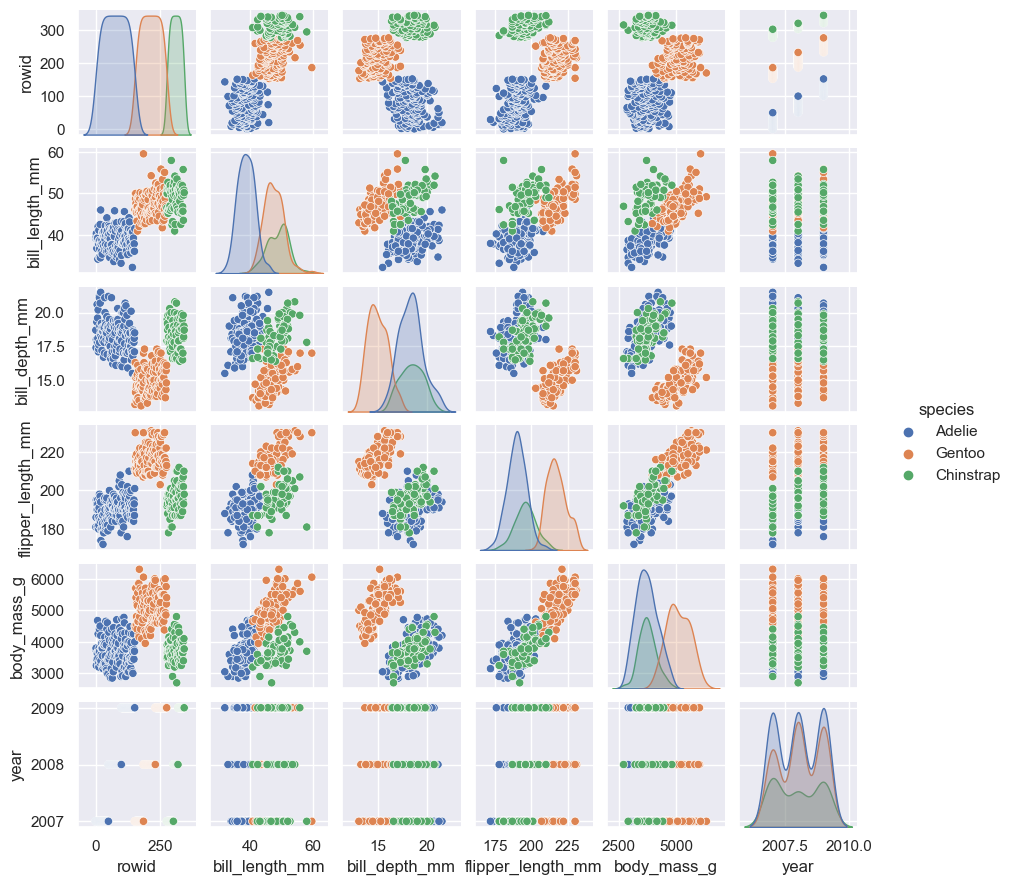

In [8]:
# Set the seaborn style for the plots
sns.set()
sns.pairplot(data1, hue = 'species', height = 1.5)

In [9]:
#This code creates a new DataFrame X_iris by dropping the column 'sex'.
X_penguin = data2.drop('species', axis = 1)
X_penguin.shape

(342, 5)

In [10]:
X_penguin

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
rowid,,,,,
1,39.1,18.7,181.0,3750.0,2007
2,39.5,17.4,186.0,3800.0,2007
3,40.3,18.0,195.0,3250.0,2007
5,36.7,19.3,193.0,3450.0,2007
6,39.3,20.6,190.0,3650.0,2007
...,...,...,...,...,...
340,55.8,19.8,207.0,4000.0,2009
341,43.5,18.1,202.0,3400.0,2009
342,49.6,18.2,193.0,3775.0,2009


In [11]:
Y_penguin = data2['species']
Y_penguin.shape

(342,)

In [12]:
Y_penguin

rowid
1         Adelie
2         Adelie
3         Adelie
5         Adelie
6         Adelie
         ...    
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
344    Chinstrap
Name: species, Length: 342, dtype: object

In [13]:
length = data2['bill_length_mm']
depth = data2['bill_depth_mm']

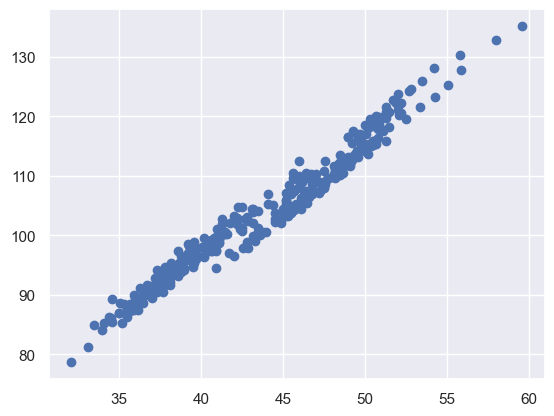

In [14]:
x = length
y = 2 * x - 1 + depth
plt.scatter(x, y);

In [15]:
data2

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
rowid,,,,,,
1,Adelie,39.1,18.7,181.0,3750.0,2007
2,Adelie,39.5,17.4,186.0,3800.0,2007
3,Adelie,40.3,18.0,195.0,3250.0,2007
5,Adelie,36.7,19.3,193.0,3450.0,2007
6,Adelie,39.3,20.6,190.0,3650.0,2007
...,...,...,...,...,...,...
340,Chinstrap,55.8,19.8,207.0,4000.0,2009
341,Chinstrap,43.5,18.1,202.0,3400.0,2009
342,Chinstrap,49.6,18.2,193.0,3775.0,2009


In [16]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_penguin, Y_penguin, random_state=1)

In [17]:
from sklearn.naive_bayes import GaussianNB
model1 = GaussianNB()
model1.fit(Xtrain, ytrain)
Y_model = model1.predict(Xtest)

In [18]:
#provide the accuracy score of the code means how well it predict.
from sklearn.metrics import accuracy_score
accuracy_score(Y_model, ytest)

0.9767441860465116